### Data Prepration + Preprocessing

In [1]:
!python Data_preprocess.py 
!python Dataset_prepare.py

                                          reviewText
0  i have used thses several times already and it...
1  i love this product especially when you use a ...
2  i have very rosy and pulpy cheeks that im not ...
3  bought x pound and am satisfied with my purcha...
4  the waffles are thin and small it takes some g...
Train tensor shape: torch.Size([35000, 100])
Vocab size: 27676
Processed data saved to: Dataset
Reading Beauty_5.json...
Collected 5000/10000 rows from Beauty_5.json
Collected 10000/10000 rows from Beauty_5.json
Reading Sports_and_Outdoors_5.json...
Collected 5000/10000 rows from Sports_and_Outdoors_5.json
Collected 10000/10000 rows from Sports_and_Outdoors_5.json
Reading Cell_Phones_and_Accessories_5.json...
Collected 5000/10000 rows from Cell_Phones_and_Accessories_5.json
Collected 10000/10000 rows from Cell_Phones_and_Accessories_5.json
Reading Home_and_Kitchen_5.json...
Collected 5000/10000 rows from Home_and_Kitchen_5.json
Collected 10000/10000 rows from Home_and_Kitch

### PART A

In [2]:
!python Part_A.py

Derived task: predict lexical diversity class (low/medium/high)
Derived bins (from train set): low < 0.760, medium < 0.869, high >= 0.869
Epoch 1/10 | train_loss=1.3367 | val_loss=1.1422 | val_sent_acc=0.8047 | val_sent_f1=0.5168 | val_der_acc=0.7752 | val_der_f1=0.7719
Epoch 2/10 | train_loss=1.0121 | val_loss=1.0136 | val_sent_acc=0.8168 | val_sent_f1=0.5547 | val_der_acc=0.7884 | val_der_f1=0.7876
Epoch 3/10 | train_loss=0.8436 | val_loss=1.0057 | val_sent_acc=0.8044 | val_sent_f1=0.5610 | val_der_acc=0.7807 | val_der_f1=0.7758
Epoch 4/10 | train_loss=0.6929 | val_loss=1.0046 | val_sent_acc=0.7896 | val_sent_f1=0.5629 | val_der_acc=0.7868 | val_der_f1=0.7856
Epoch 5/10 | train_loss=0.4988 | val_loss=1.0494 | val_sent_acc=0.7951 | val_sent_f1=0.5698 | val_der_acc=0.7941 | val_der_f1=0.7928
Epoch 6/10 | train_loss=0.3200 | val_loss=1.3018 | val_sent_acc=0.7133 | val_sent_f1=0.5435 | val_der_acc=0.7832 | val_der_f1=0.7795
Epoch 7/10 | train_loss=-0.0417 | val_loss=1.8630 | val_sent_acc

### PART B

In [3]:
!python Part_B.py

Stored retrieval index at: /root/NLP_Asst3/i23-2619-NLP-Assignment3/results/retrieval_index.pt
Stored retrieval metrics at: /root/NLP_Asst3/i23-2619-NLP-Assignment3/results/retrieval_metrics.csv
Stored retrieval examples at: /root/NLP_Asst3/i23-2619-NLP-Assignment3/results/retrieval_examples.csv
Stored decoder contexts at: /root/NLP_Asst3/i23-2619-NLP-Assignment3/results/decoder_contexts.csv
Sample decoder context length: 1013


### PART C

In [4]:
!python Part_C.py

Training full RAG decoder (with retrieval)...
Epoch 1/3 | train_loss=1.4790 | val_loss=0.4064
Epoch 2/3 | train_loss=0.5154 | val_loss=0.1982
Epoch 3/3 | train_loss=0.3208 | val_loss=0.1536
Training baseline decoder (no retrieval)...
Epoch 1/3 | train_loss=1.9626 | val_loss=1.0598
Epoch 2/3 | train_loss=0.9589 | val_loss=0.3564
Epoch 3/3 | train_loss=0.5577 | val_loss=0.2335
Saved Part C metrics to: /root/NLP_Asst3/i23-2619-NLP-Assignment3/results/part_c_metrics.csv
Saved generated examples to: /root/NLP_Asst3/i23-2619-NLP-Assignment3/results/part_c_generated_examples.csv
Saved tuning log to: /root/NLP_Asst3/i23-2619-NLP-Assignment3/results/part_c_tuning_log.csv
Perplexity (full): 1.1682
Perplexity (baseline): 1.2635


## Bonus: Advanced Visualization and Analysis (5 Marks)

This section adds advanced reporting features:
- publication-style plots for Part A, Part B, and Part C
- automatic best-trial extraction from hyperparameter tuning logs
- quantified RAG gain analysis (absolute + percentage)
- compact dashboard-style output for quick grading

Run the next cell after running Part A/Part B/Part C.

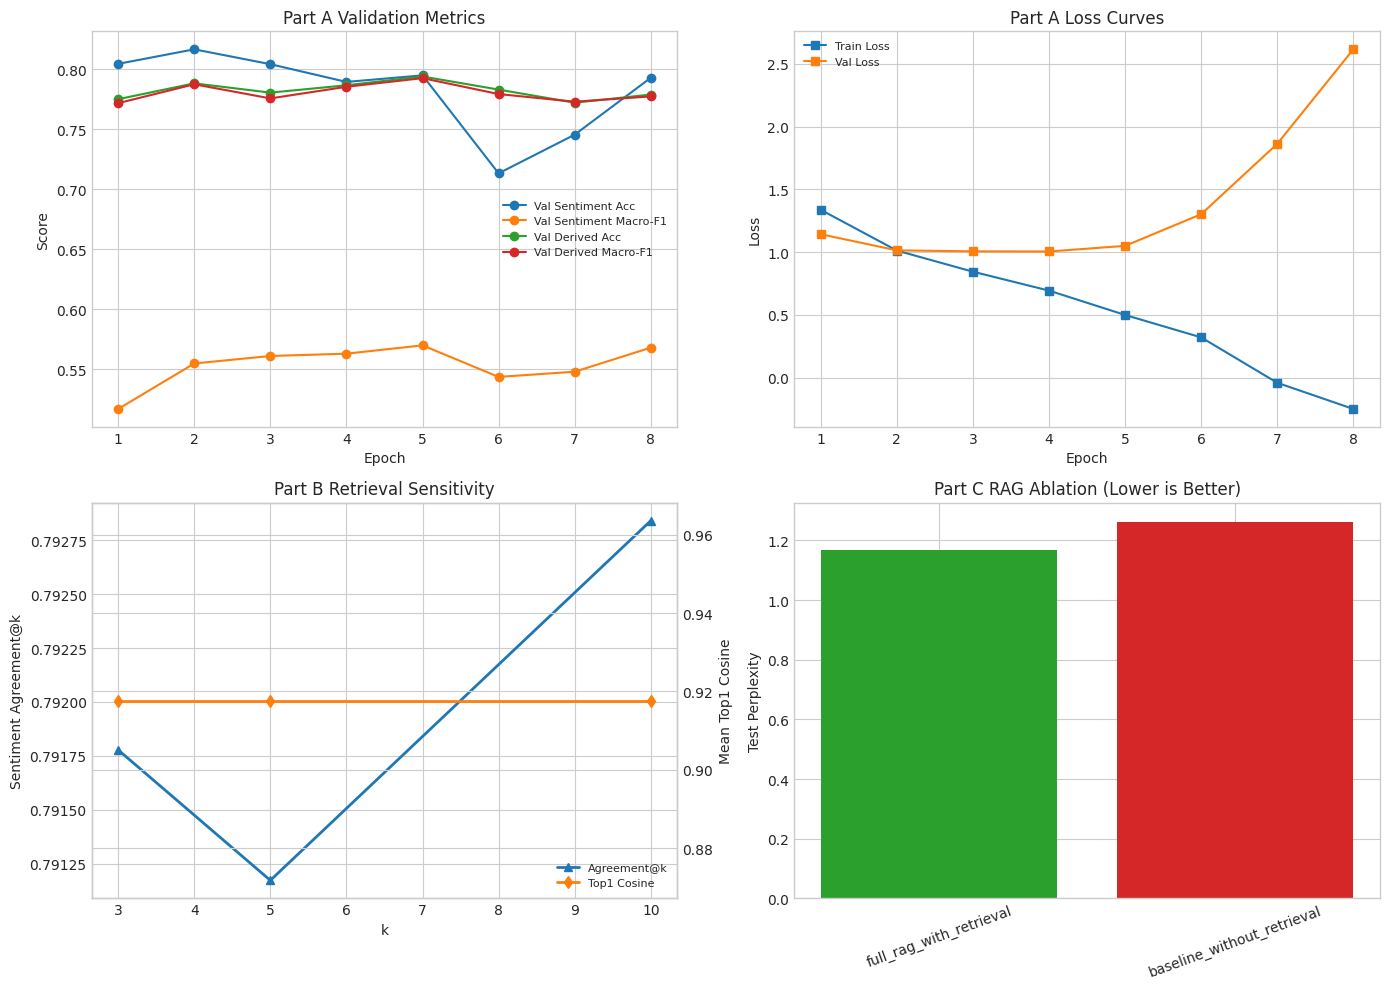

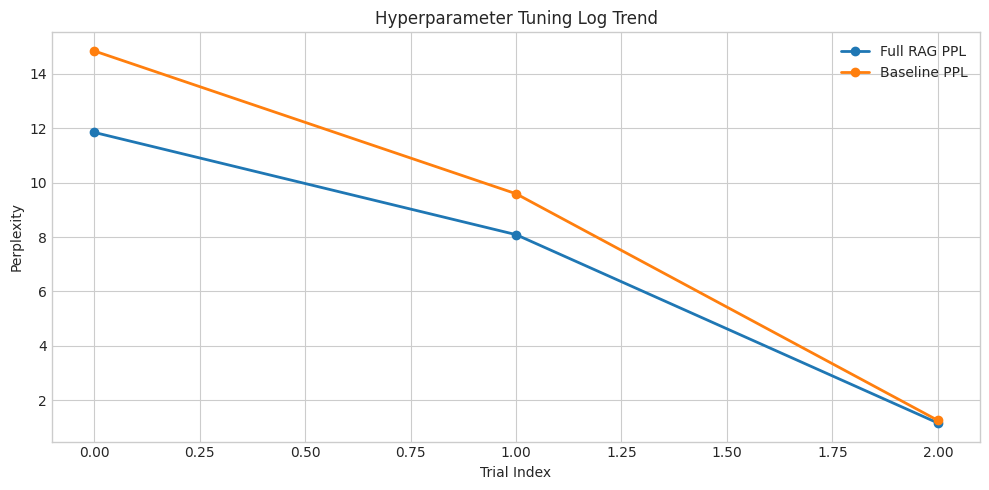

BONUS ANALYTICS SUMMARY
RAG vs Baseline (Perplexity): 1.1682 vs 1.2635
Absolute gain (baseline - RAG): 0.0953
Relative gain: 7.54% lower perplexity with retrieval
------------------------------------------------------------
Best full-RAG trial index: 2
lr                0.001000
layers            2.000000
d_model         128.000000
heads             4.000000
ff_dim          256.000000
dropout           0.200000
batch_size       16.000000
epochs            3.000000
ppl_full          1.168176
ppl_baseline      1.263500
------------------------------------------------------------
Best baseline trial index: 2
lr                0.001000
layers            2.000000
d_model         128.000000
heads             4.000000
ff_dim          256.000000
dropout           0.200000
batch_size       16.000000
epochs            3.000000
ppl_full          1.168176
ppl_baseline      1.263500


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

RESULTS_DIR = "results"

paths = {
    "learning": os.path.join(RESULTS_DIR, "learning_curves.csv"),
    "retrieval": os.path.join(RESULTS_DIR, "retrieval_metrics.csv"),
    "partc": os.path.join(RESULTS_DIR, "part_c_metrics.csv"),
    "tuning": os.path.join(RESULTS_DIR, "part_c_tuning_log.csv"),
}

missing = [k for k, v in paths.items() if not os.path.exists(v)]
if missing:
    raise FileNotFoundError(f"Missing result files for: {missing}. Run Part_A.py, Part_B.py, and Part_C.py first.")

learning_df = pd.read_csv(paths["learning"])
retrieval_df = pd.read_csv(paths["retrieval"])
partc_df = pd.read_csv(paths["partc"])
tuning_df = pd.read_csv(paths["tuning"])

# -----------------------------
# Figure 1: Multi-panel dashboard
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Part A metrics curves
ax = axes[0, 0]
ax.plot(learning_df["epoch"], learning_df["val_sentiment_acc"], marker="o", label="Val Sentiment Acc")
ax.plot(learning_df["epoch"], learning_df["val_sentiment_macro_f1"], marker="o", label="Val Sentiment Macro-F1")
ax.plot(learning_df["epoch"], learning_df["val_derived_acc"], marker="o", label="Val Derived Acc")
ax.plot(learning_df["epoch"], learning_df["val_derived_macro_f1"], marker="o", label="Val Derived Macro-F1")
ax.set_title("Part A Validation Metrics")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.legend(fontsize=8)

# Part A loss curves
ax = axes[0, 1]
ax.plot(learning_df["epoch"], learning_df["train_loss"], marker="s", label="Train Loss")
ax.plot(learning_df["epoch"], learning_df["val_loss"], marker="s", label="Val Loss")
ax.set_title("Part A Loss Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=8)

# Part B retrieval sensitivity
ax = axes[1, 0]
ax.plot(retrieval_df["k"], retrieval_df["sentiment_agreement_at_k"], marker="^", linewidth=2, label="Agreement@k")
ax2 = ax.twinx()
ax2.plot(retrieval_df["k"], retrieval_df["mean_top1_cosine"], marker="d", color="tab:orange", linewidth=2, label="Top1 Cosine")
ax.set_title("Part B Retrieval Sensitivity")
ax.set_xlabel("k")
ax.set_ylabel("Sentiment Agreement@k")
ax2.set_ylabel("Mean Top1 Cosine")

lns1, lbs1 = ax.get_legend_handles_labels()
lns2, lbs2 = ax2.get_legend_handles_labels()
ax.legend(lns1 + lns2, lbs1 + lbs2, fontsize=8, loc="lower right")

# Part C ablation bar chart
ax = axes[1, 1]
ax.bar(partc_df["system"], partc_df["test_perplexity"], color=["tab:green", "tab:red"])
ax.set_title("Part C RAG Ablation (Lower is Better)")
ax.set_ylabel("Test Perplexity")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# -----------------------------
# Figure 2: Hyperparameter tuning trend
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(tuning_df.index, tuning_df["ppl_full"], marker="o", linewidth=2, label="Full RAG PPL")
plt.plot(tuning_df.index, tuning_df["ppl_baseline"], marker="o", linewidth=2, label="Baseline PPL")
plt.title("Hyperparameter Tuning Log Trend")
plt.xlabel("Trial Index")
plt.ylabel("Perplexity")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Bonus analytics summary
# -----------------------------
full_row = partc_df[partc_df["system"].str.contains("full", case=False)].iloc[0]
base_row = partc_df[partc_df["system"].str.contains("baseline", case=False)].iloc[0]

ppl_full = float(full_row["test_perplexity"])
ppl_base = float(base_row["test_perplexity"])
abs_gain = ppl_base - ppl_full
pct_gain = (abs_gain / ppl_base) * 100 if ppl_base else 0.0

best_full_idx = tuning_df["ppl_full"].idxmin()
best_base_idx = tuning_df["ppl_baseline"].idxmin()

print("=" * 60)
print("BONUS ANALYTICS SUMMARY")
print("=" * 60)
print(f"RAG vs Baseline (Perplexity): {ppl_full:.4f} vs {ppl_base:.4f}")
print(f"Absolute gain (baseline - RAG): {abs_gain:.4f}")
print(f"Relative gain: {pct_gain:.2f}% lower perplexity with retrieval")
print("-" * 60)
print(f"Best full-RAG trial index: {best_full_idx}")
print(tuning_df.loc[best_full_idx].to_string())
print("-" * 60)
print(f"Best baseline trial index: {best_base_idx}")
print(tuning_df.loc[best_base_idx].to_string())
print("=" * 60)